In [1]:
import numpy as np
from astropy.io import fits
from datetime import datetime
import matplotlib.pyplot as plt
import glob
import pandas as pd
from dateutil import parser
from astropy.timeseries import LombScargle

In [2]:
filenames = glob.glob('/home/miles-group/seekcamera-python/examples/DATA/12_hour_shutter_off_calibration/2026-04-09_20-14-39_12_hour/E05257AC071D/converted_fits/*.fits')
imagedata = [None] * len(filenames)

In [3]:
#start_header will get the header of the fits images, starting with the first image.
#start_time will take the DATE_OBS part of whichever fits file the previous variable is on.
start_header = fits.getheader(filenames[0])
start_time = datetime.strptime(start_header['DATE-OBS'], "%Y-%m-%dT%H:%M:%S.%f")
files_with_times = []

for i in filenames:
    hdr = fits.getheader(i)
    t = parser.parse(hdr['DATE-OBS'])
    files_with_times.append((i, t))

files_with_times.sort(key=lambda x: x[1])

filenames = [ft[0] for ft in files_with_times]
times = [ft[1] for ft in files_with_times]

start_time = times[0]


#This loop will order each file in terms of time. 
for j, current_time in zip(filenames, times):
    with fits.open(j, mode='update') as hdul:
        header = hdul[0].header
        delta_time = (current_time - start_time).total_seconds()
        header['DELTAT'] = (delta_time, 'Time since first frame (chronological)')
        hdul.flush()

In [4]:
#image_header will get the header of whichever image you would like
image_header = fits.getheader(filenames[10000])
print(image_header) 


SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                  -32 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  200                                                  NAXIS2  =                  150                                                  DATE-OBS= '2026-04-09T20:23:39.296211'                                          CHIP_ID = 'E05257AC071D'                                                        ENV_TEMP= 'N/A     '                                                            AGC_MODE= 'HISTOGRAM'                                                           SHUTTER = 'MANUAL  '                                                            DELTAT  =           539.677066 / Time since first frame (chronological)         END                                                                                                                     

In [5]:
#all 3 variables will make an array of all 0s the length of filenames, which is the amount of images
fluxes = np.zeros(len(filenames))
fluxes_mean = np.zeros(len(filenames))
times = np.zeros(len(filenames))


for i, filename in enumerate(filenames):
    image = fits.getdata(filename) 
    header = fits.getheader(filename)
    
    flux = image[0,0]
    fluxes[i] = flux
    
    flux_mean = np.mean(image)
    fluxes_mean[i] = flux_mean

    try:
        obs_time = datetime.strptime(header['DATE-OBS'], "%Y-%m-%dT%H:%M:%S.%f")
    except ValueError:
        obs_time = datetime.strptime(header['DATE-OBS'], "%Y-%m-%dT%H:%M:%S")
    times[i] = (obs_time - start_time).total_seconds()
#print(fluxes)

<function matplotlib.pyplot.show(close=None, block=None)>

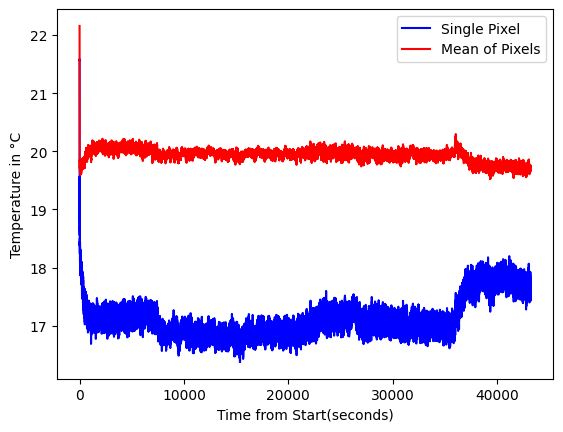

In [6]:
plt.figure('Brightness Changes')
plt.plot(times, fluxes, 'b', label = 'Single Pixel')
plt.plot(times, fluxes_mean, 'r', label = 'Mean of Pixels')
plt.legend()
#plt.xlim(3600,3700)
plt.xlabel('Time from Start(seconds)')
plt.ylabel('Temperature in °C')
plt.show

In [7]:
#Gets the average temp of all the images
average_temp = np.trapezoid(fluxes, times) / (times[-1]-times[0])
print('Average T of all images = ', round(average_temp, 5),  '\u00b0C')
y_min = min(fluxes)
print('Minimum T of all images = ', round(y_min, 5), '\u00b0C')
y_max = max(fluxes)
print('Maximum T of all images = ', round(y_max, 5), '\u00b0C')

Average T of all images =  17.14706 °C
Minimum T of all images =  16.37672 °C
Maximum T of all images =  21.58891 °C


In [8]:
#Gets the average temp of all the images
average_temp = np.trapezoid(fluxes, times) / (times[-1]-times[0])
print('Average T of all images = ', round(average_temp, 5),  '\u00b0C')
y_min = min(filenames[100])
print('Minimum T of images = ', y_min, '\u00b0C')
#y_max = max(fluxes[100])
#print('Maximum T of images = ', round(y_max, 5), '\u00b0C')

Average T of all images =  17.14706 °C
Minimum T of images =  - °C


In [ ]:
all_pixels = []
for j in filenames:
    data = fits.getdata(j)
    all_pixels.append(data.flatten())

all_pixels = np.concatenate(all_pixels)
std_global = np.std(all_pixels, ddof=1)
print('Standard Deviation across all files:', std_global)

In [ ]:
#x = np.arange(len(fluxes))
#x_2 = np.arange(len(fluxes_mean))
x = times
frequency, power = LombScargle(x, fluxes).autopower()
fig, ax = plt.subplots()
ax.plot(1/frequency, power)
plt.xlim([0.1,100])
plt.xlabel('Frequency')
plt.ylabel('Power')
plt.xscale('log')
